In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

### Load & Concatenate All Countries

In [48]:
countries = ["ethiopia", "kenya", "nigeria", "tanzania", "sudan"]

dfs = []

for c in countries:
    df = pd.read_csv(rf"C:\Users\pc\Desktop\Week_0\climate_challenge_week_0\data/{c}_clean.csv")
    df["Country"] = c.capitalize()
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,YearMonth
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1,2015-01
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1,2015-01
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1,2015-01
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1,2015-01
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1,2015-01


### Temperature Trend Comparison

In [58]:
data["Date"] = pd.to_datetime(data["Date"])
data["YearMonth"] = data["Date"].dt.to_period("M")

In [59]:
monthly_temp = data.groupby(["Country", "YearMonth"])["T2M"].mean().reset_index()

monthly_temp["YearMonth"] = monthly_temp["YearMonth"].dt.to_timestamp()

monthly_temp.head()

,Country,YearMonth,T2M
0,Ethiopia,2015-01-01,14.211935
1,Ethiopia,2015-02-01,16.864643
2,Ethiopia,2015-03-01,17.995161
3,Ethiopia,2015-04-01,19.302333
4,Ethiopia,2015-05-01,18.205806


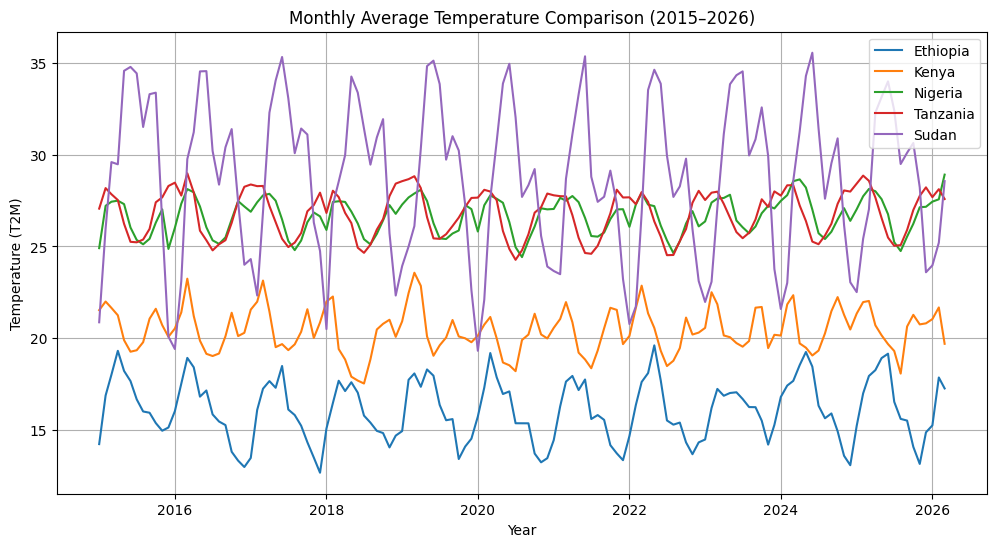

In [60]:
plt.figure(figsize=(12,6))

for country in countries:
    subset = monthly_temp[monthly_temp["Country"] == country.capitalize()]
    plt.plot(subset["YearMonth"], subset["T2M"], label=country.capitalize())

plt.title("Monthly Average Temperature Comparison (2015–2026)")
plt.xlabel("Year")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.grid(True)

plt.show()

In [61]:
summary_stats = data.groupby("Country")["T2M"].agg([
    "mean",
    "median",
    "std"
]).reset_index()

summary_stats

,Country,mean,median,std
0,Ethiopia,16.068500,16.04,1.898050
1,Kenya,20.427600,20.36,1.440824
2,Nigeria,26.656928,26.82,1.123335
3,Sudan,28.759007,29.16,4.681305
4,Tanzania,26.802422,26.99,1.325388


In [62]:
summary_stats = summary_stats.sort_values("mean", ascending=False)
summary_stats

,Country,mean,median,std
3,Sudan,28.759007,29.16,4.681305
4,Tanzania,26.802422,26.99,1.325388
2,Nigeria,26.656928,26.82,1.123335
1,Kenya,20.427600,20.36,1.440824
0,Ethiopia,16.068500,16.04,1.898050


### Precipitation Variability Comparison

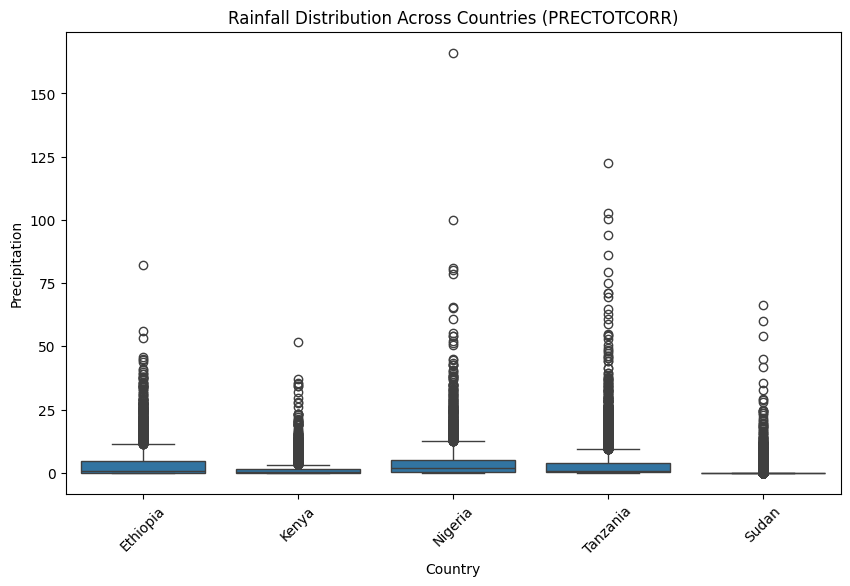

In [65]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=data,
    x="Country",
    y="PRECTOTCORR"
)

plt.title("Rainfall Distribution Across Countries (PRECTOTCORR)")
plt.xlabel("Country")
plt.ylabel("Precipitation")

plt.xticks(rotation=45)
plt.show()

In [66]:
rain_summary = data.groupby("Country")["PRECTOTCORR"].agg([
    "mean",
    "median",
    "std"
]).reset_index()

rain_summary

,Country,mean,median,std
0,Ethiopia,3.633795,0.82,6.289061
1,Kenya,1.468162,0.38,3.180228
2,Nigeria,4.213914,1.84,7.266742
3,Sudan,0.643875,0.00,3.057672
4,Tanzania,3.740256,0.64,8.003947


In [67]:
rain_summary = rain_summary.sort_values("mean", ascending=False)
rain_summary

,Country,mean,median,std
2,Nigeria,4.213914,1.84,7.266742
4,Tanzania,3.740256,0.64,8.003947
0,Ethiopia,3.633795,0.82,6.289061
1,Kenya,1.468162,0.38,3.180228
3,Sudan,0.643875,0.00,3.057672


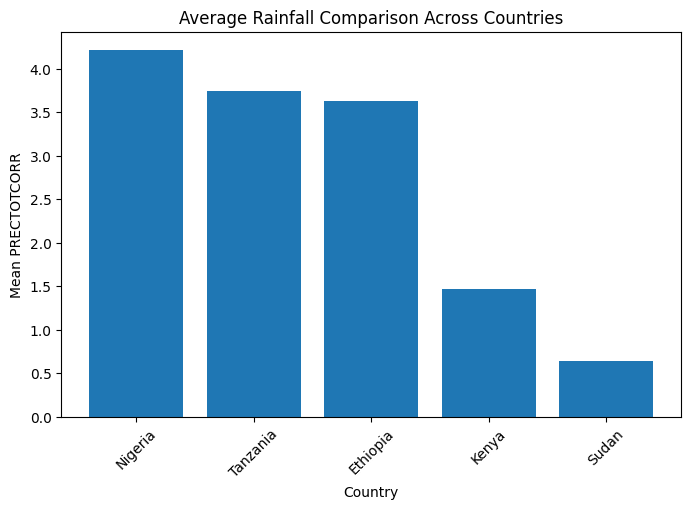

In [68]:
plt.figure(figsize=(8,5))

plt.bar(rain_summary["Country"], rain_summary["mean"])

plt.title("Average Rainfall Comparison Across Countries")
plt.xlabel("Country")
plt.ylabel("Mean PRECTOTCORR")

plt.xticks(rotation=45)
plt.show()

### Extreme Event Frequency

In [69]:
data["Extreme_Heat"] = data["T2M_MAX"] > 35

In [70]:
data["Year"] = data["Date"].dt.year

heat_days = data.groupby(["Country", "Year"])["Extreme_Heat"].sum().reset_index()

heat_days.head()

,Country,Year,Extreme_Heat
0,Ethiopia,2015,0
1,Ethiopia,2016,0
2,Ethiopia,2017,0
3,Ethiopia,2018,0
4,Ethiopia,2019,0


In [71]:
heat_summary = heat_days.groupby("Country")["Extreme_Heat"].mean().reset_index()

heat_summary

,Country,Extreme_Heat
0,Ethiopia,0.0
1,Kenya,0.0
2,Nigeria,0.0
3,Sudan,224.5
4,Tanzania,0.0


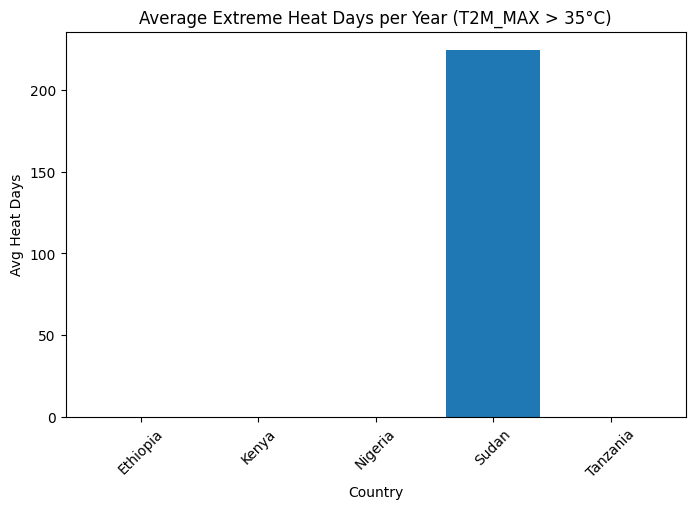

In [72]:
plt.figure(figsize=(8,5))

plt.bar(heat_summary["Country"], heat_summary["Extreme_Heat"])

plt.title("Average Extreme Heat Days per Year (T2M_MAX > 35°C)")
plt.xlabel("Country")
plt.ylabel("Avg Heat Days")

plt.xticks(rotation=45)
plt.show()

In [73]:
data = data.sort_values(["Country", "Date"])

data["Dry_Day"] = data["PRECTOTCORR"] < 1

In [74]:
def max_dry_streak(series):
    max_streak = 0
    current_streak = 0

    for val in series:
        if val:
            current_streak += 1
            max_streak = max(max_streak, current_streak)
        else:
            current_streak = 0

    return max_streak

In [75]:
dry_streaks = data.groupby(["Country", "Year"])["Dry_Day"].apply(max_dry_streak).reset_index()

dry_streaks.head()

,Country,Year,Dry_Day
0,Ethiopia,2015,25
1,Ethiopia,2016,35
2,Ethiopia,2017,43
3,Ethiopia,2018,35
4,Ethiopia,2019,46


In [76]:
dry_summary = dry_streaks.groupby("Country")["Dry_Day"].mean().reset_index()

dry_summary

,Country,Dry_Day
0,Ethiopia,37.916667
1,Kenya,41.083333
2,Nigeria,35.833333
3,Sudan,142.750000
4,Tanzania,40.250000


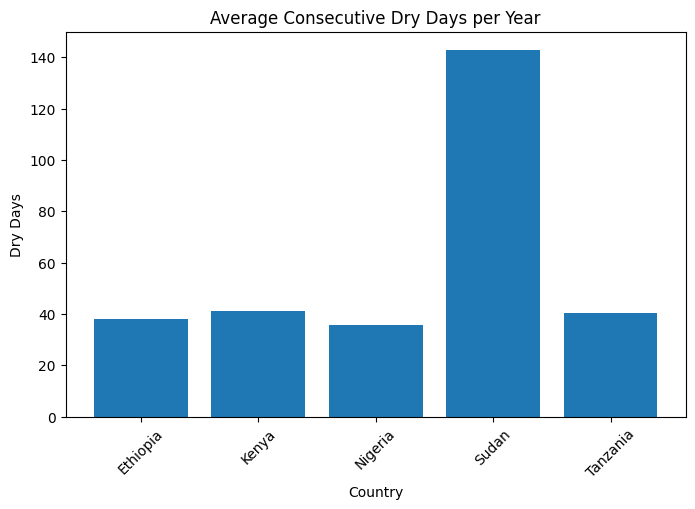

In [77]:
plt.figure(figsize=(8,5))

plt.bar(dry_summary["Country"], dry_summary["Dry_Day"])

plt.title("Average Consecutive Dry Days per Year")
plt.xlabel("Country")
plt.ylabel("Dry Days")

plt.xticks(rotation=45)
plt.show()

### Statistical Testing 

In [78]:
from scipy import stats

countries = data["Country"].unique()

groups = [data[data["Country"] == c]["T2M"].dropna() for c in countries]

In [79]:
f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA F-statistic:", f_stat)
print("p-value:", p_value)

ANOVA F-statistic: 18938.7456970699
p-value: 0.0


In [80]:
h_stat, p_value_kw = stats.kruskal(*groups)

print("Kruskal-Wallis H-statistic:", h_stat)
print("p-value:", p_value_kw)

Kruskal-Wallis H-statistic: 15392.992231563152
p-value: 0.0


### Vulnerability Ranking & Key Observations

In [ ]:
# Create a vulnerability score based on temperature variabilty, rainfall variability, and freuency of extereme heat and dry days
data["Year"] = data["Date"].dt.year

summary = data.groupby("Country").agg({
    "T2M": "mean",
    "PRECTOTCORR": ["mean", "std"],
    "T2M_MAX": "mean"
}).reset_index()

summary.columns = [
    "Country",
    "Avg_Temperature",
    "Avg_Rainfall",
    "Rainfall_Variability",
    "Avg_Max_Temp"
]

summary

,Country,Avg_Temperature,Avg_Rainfall,Rainfall_Variability,Avg_Max_Temp
0,Ethiopia,16.068500,3.633795,6.289061,23.199175
1,Kenya,20.427600,1.468162,3.180228,27.838717
2,Nigeria,26.656928,4.213914,7.266742,28.914667
3,Sudan,28.759007,0.643875,3.057672,36.773914
4,Tanzania,26.802422,3.740256,8.003947,29.163493


In [ ]:
# Extreme heat days
data["Extreme_Heat"] = data["T2M_MAX"] > 35

heat = data.groupby("Country")["Extreme_Heat"].mean().reset_index()
heat.columns = ["Country", "Heat_Frequency"]

In [ ]:
# Dry spell intensity
data["Dry_Day"] = data["PRECTOTCORR"] < 1

dry = data.groupby("Country")["Dry_Day"].mean().reset_index()
dry.columns = ["Country", "Dry_Frequency"]

In [ ]:
# Merge all indicators
vuln = summary.merge(heat, on="Country").merge(dry, on="Country")

vuln

,Country,Avg_Temperature,Avg_Rainfall,Rainfall_Variability,Avg_Max_Temp,Heat_Frequency,Dry_Frequency
0,Ethiopia,16.068500,3.633795,6.289061,23.199175,0.000000,0.526047
1,Kenya,20.427600,1.468162,3.180228,27.838717,0.000000,0.689143
2,Nigeria,26.656928,4.213914,7.266742,28.914667,0.000000,0.388267
3,Sudan,28.759007,0.643875,3.057672,36.773914,0.655794,0.899708
4,Tanzania,26.802422,3.740256,8.003947,29.163493,0.000000,0.560613


### Create Vulnerability Score (Ranking)

In [85]:
from sklearn.preprocessing import MinMaxScaler

cols = [
    "Avg_Temperature",
    "Rainfall_Variability",
    "Heat_Frequency",
    "Dry_Frequency"
]

scaler = MinMaxScaler()

vuln_scaled = vuln.copy()
vuln_scaled[cols] = scaler.fit_transform(vuln[cols])

vuln_scaled["Vulnerability_Score"] = (
    vuln_scaled["Avg_Temperature"] * 0.25 +
    vuln_scaled["Rainfall_Variability"] * 0.25 +
    vuln_scaled["Heat_Frequency"] * 0.25 +
    vuln_scaled["Dry_Frequency"] * 0.25
)
ranking = vuln_scaled.sort_values("Vulnerability_Score", ascending=False)

ranking

,Country,Avg_Temperature,Avg_Rainfall,Rainfall_Variability,Avg_Max_Temp,Heat_Frequency,Dry_Frequency,Vulnerability_Score
3,Sudan,1.000000,0.643875,0.000000,36.773914,1.0,1.000000,0.750000
4,Tanzania,0.845823,3.740256,1.000000,29.163493,0.0,0.336982,0.545701
2,Nigeria,0.834358,4.213914,0.850958,28.914667,0.0,0.000000,0.421329
1,Kenya,0.343493,1.468162,0.024777,27.838717,0.0,0.588291,0.239140
0,Ethiopia,0.000000,3.633795,0.653297,23.199175,0.0,0.269396,0.230673


### Visualize Ranking

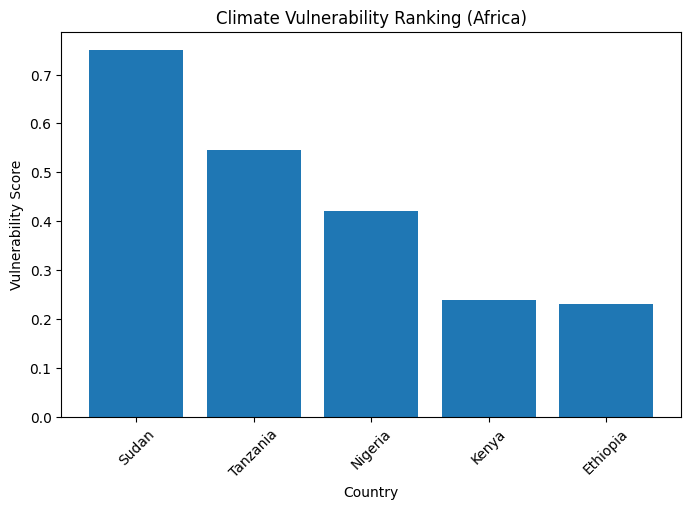

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(ranking["Country"], ranking["Vulnerability_Score"])

plt.title("Climate Vulnerability Ranking (Africa)")
plt.xlabel("Country")
plt.ylabel("Vulnerability Score")

plt.xticks(rotation=45)
plt.show()